# 福州大学数学与统计学院

## 2025-2026 学年第 2 学期《数据分析与可视化》期末考试答题模板

- 考试时间：2026年06月24日 14:00-17:30
- 考试地点：旗山东2-102
- 考试人数：44 人

> 文件命名建议：`学号_姓名_期末考试.ipynb`

请在提交前从头到尾顺序运行一次 Notebook，确认所有代码无报错，图表和结果完整显示。

## 教师评分区

> 本区域由教师评分时填写，学生不要删除。

| 评分项目 | 满分 | 得分 | 评语 |
|---|---:|---:|---|
| Notebook 规范与可运行性 | 10 |  |  |
| Markdown 表达与报告组织 | 8 |  |  |
| 数据读取与初步理解 | 7 |  |  |
| 数据质量检查 | 7 |  |  |
| 数据清洗与类型转换 | 13 |  |  |
| `pandas` / `numpy` 数据分析能力 | 15 |  |  |
| 可视化能力 | 15 |  |  |
| 分析深度与结论质量 | 20 |  |  |
| GitHub 提交合规性 | 5 |  |  |
| **最终得分** | **100** |  |  |

## 学生信息

- 专业：经济统计学
- 学号：032402124
- 姓名：唐萍凡
- GitHub 仓库链接：https://github.com/FZU-Data-Analysis-and-Visualization/join-github-classroom-TTT-123456
- 数据文件：`ershoufang_list.csv`

# 福州市二手房市场数据分析报告
## 1.摘要
本次分析以福州市二手房挂牌数据为研究样本，围绕区域价格差异、市场供给结构、总价分布特征、房价核心影响因素四大核心问题展开系统研究。数据处理层面，通过正则提取完成了面积、总价、均价等带单位文本字段的数值化转换，对户型、楼层等复合字段进行结构化拆分，并完成了缺失值、异常值与重复值的全面校验清洗；分析过程中运用 pandas 实现分组聚合、描述统计与交叉分析，同时结合柱状图、直方图、散点图、箱线图、饼图等多种可视化方式直观呈现市场特征。研究发现，福州二手房市场呈现显著的圈层价格分化，核心城区房价远高于远郊县域；市场供给以三居室刚需刚改房源为绝对主力，总价分布呈右偏特征，购房总价中位数约 173 万元；房屋建筑面积与总价存在显著正相关关系，且大户型房源的价格分化程度更强。

## 2. 数据读取与基本概览
首先导入分析所需的工具库，并读取 CSV 原始数据，查看数据基本规模与结构。

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

# 全局设置
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
sns.set_style("whitegrid", {"font.sans-serif": ['SimHei']})

# 读取CSV文件，自动识别表头
df = pd.read_csv('ershoufang_list.csv', encoding='utf-8')

print("=== 当前数据的所有列名 ===")
print(df.columns.tolist())
print("\n=== 数据前5行预览 ===")
display(df.head())
print(f"\n数据集整体规模：共 {df.shape[0]} 条房源，{df.shape[1]} 个字段")

=== 当前数据的所有列名 ===
['id', '城市', '市区', '标题', '户型', '面积', '面积数值', '方位', '楼层', '时间', '所属小区', '所属区域', '房源链接', '总价', '总价数值', '均价', '均价数值', '房龄']

=== 数据前5行预览 ===


,id,城市,市区,标题,户型,面积,面积数值,方位,楼层,时间,所属小区,所属区域,房源链接,总价,总价数值,均价,均价数值,房龄
0,1,fuzhou,台江,近医科大 西洋宁化地铁25年次新房 头排无遮挡 首付仅30万,3 室 2 厅 2 卫,103㎡,103.0,南北,中层(共31层),2025年建造,榕发望熙雅筑B区,台江 万宝 交通西路,https://fz.anjuke.com/prop/view/S4605513392729...,199万,199.0,19321元/㎡,19321.0,2年内
1,2,fuzhou,晋安,来电可大刀 建发望樾盘精装3房 地铁口 低密宜居 精装好房,3 室 2 厅 2 卫,83㎡,83.0,南北,低层(共18层),2025年建造,国贸保利和颂锦原,晋安 五四北 坂中路,https://fz.anjuke.com/prop/view/S4248588093856...,181万,181.0,21808元/㎡,21808.0,2年内
2,3,fuzhou,晋安,锦鸿佳园，五里亭地铁口，电梯高层，精装拎包入住，周边配套成熟,3 室 2 厅 1 卫,90㎡,90.0,南北,高层(共33层),2024年建造,锦鸿佳园,晋安 福马路 七贤路2号,https://fz.anjuke.com/prop/view/S4537384389565...,159万,159.0,17667元/㎡,17667.0,2年内
3,4,fuzhou,鼓楼,湖滨小隔壁十八中临近西次湖新房地铁4号线,3 室 2 厅 1 卫,90㎡,90.0,南北,低层(共7层),2025年建造,凯佳湖岸公馆,鼓楼 东街 湖头街,https://fz.anjuke.com/prop/view/S4514662328474...,300万,300.0,33334元/㎡,33334.0,2年内
4,5,fuzhou,晋安,保利招商和樾风华 3室2厅2卫,3 室 2 厅 2 卫,107㎡,107.0,南北,低层(共18层),2024年建造,保利招商和樾风华,晋安 王庄 连洋西路,https://fz.anjuke.com/prop/view/S4201934614372...,330万,330.0,30842元/㎡,30842.0,2年内



数据集整体规模：共 11856 条房源，18 个字段


## 3. 数据质量检查与字段说明
### 3.1 字段含义说明
根据数据定义与实际内容，各字段核心含义如下：
| 字段 | 含义 |
|------|------|
| id | 房源唯一编号 |
| 市区 | 房源所属行政区 |
| 户型 | 房屋室/厅/卫描述 |
| 面积_文本 | 带单位的面积原始文本 |
| 朝向 | 房屋朝向 |
| 楼层_文本 | 楼层位置与总层数描述 |
| 建造时间_文本 | 带后缀的建造年份 |
| 总价_文本 | 带单位的总价原始文本 |
| 均价_文本 | 带单位的单价原始文本 |
| 房龄 | 房龄分段分类 |

### 3.2 缺失值、重复值与数据类型检查

In [2]:
print("=== 各字段数据类型与非空数量 ===")
df.info()

print("\n=== 各字段缺失值统计 ===")
print(df.isnull().sum())

print(f"\n=== 重复值数量：{df.duplicated().sum()} 条 ===")

print("\n=== 数值字段基础描述统计 ===")
display(df[['面积数值', '总价数值', '均价数值']].describe().round(2))

=== 各字段数据类型与非空数量 ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11856 entries, 0 to 11855
Data columns (total 18 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   id      11856 non-null  int64  
 1   城市      11856 non-null  object 
 2   市区      11856 non-null  object 
 3   标题      11856 non-null  object 
 4   户型      11856 non-null  object 
 5   面积      11856 non-null  object 
 6   面积数值    11856 non-null  float64
 7   方位      11856 non-null  object 
 8   楼层      11856 non-null  object 
 9   时间      11856 non-null  object 
 10  所属小区    11856 non-null  object 
 11  所属区域    11856 non-null  object 
 12  房源链接    11856 non-null  object 
 13  总价      11830 non-null  object 
 14  总价数值    11830 non-null  float64
 15  均价      11830 non-null  object 
 16  均价数值    11830 non-null  float64
 17  房龄      11856 non-null  object 
dtypes: float64(3), int64(1), object(14)
memory usage: 1.6+ MB

=== 各字段缺失值统计 ===
id       0
城市       0
市区       0
标题       0
户型   

,面积数值,总价数值,均价数值
count,11856.00,11830.00,11830.00
mean,97.89,190.76,19235.60
std,25.92,111.17,6925.95
min,18.00,16.80,2169.00
25%,84.73,130.00,15298.25
50%,93.00,173.00,18325.50
75%,113.01,225.00,22268.50
max,500.00,3180.00,92968.00


## 4. 数据清洗与特征工程
为体现数据清洗能力，我们**从带单位的原始文本中提取数值**，不直接使用现成的数值列；同时拆分户型、楼层等复合字段，生成可用于分析的结构化特征。

### 4.1 数值型文本清洗
从带单位的文本中提取纯数字：面积（㎡）、总价（万元）、均价（元/㎡）、建造年份。

In [3]:
# 定义通用函数：从文本中提取第一个数字
def extract_number(text):
    if pd.isna(text):
        return np.nan
    nums = re.findall(r'\d+\.?\d*', str(text))
    return float(nums[0]) if nums else np.nan

# 批量提取数值
df['面积(㎡)'] = df['面积'].apply(extract_number)
df['总价(万)'] = df['总价'].apply(extract_number)
df['均价(元/㎡)'] = df['均价'].apply(extract_number)
df['建造年份'] = df['时间'].apply(extract_number).astype('Int64')

# 预览清洗结果
print("数值字段清洗效果预览：")
display(df[['面积', '面积(㎡)', '总价', '总价(万)', '均价', '均价(元/㎡)', '时间', '建造年份']].head())

数值字段清洗效果预览：


,面积,面积(㎡),总价,总价(万),均价,均价(元/㎡),时间,建造年份
0,103㎡,103.0,199万,199.0,19321元/㎡,19321.0,2025年建造,2025
1,83㎡,83.0,181万,181.0,21808元/㎡,21808.0,2025年建造,2025
2,90㎡,90.0,159万,159.0,17667元/㎡,17667.0,2024年建造,2024
3,90㎡,90.0,300万,300.0,33334元/㎡,33334.0,2025年建造,2025
4,107㎡,107.0,330万,330.0,30842元/㎡,30842.0,2024年建造,2024


处理操作：针对面积、总价、均价、建造年份四个核心字段，使用正则表达式从带单位的原始文本（如89.5㎡、230万、21000元/㎡、2015年建）中提取纯数字，统一转换为浮点型或整型数值，生成独立的分析字段。

处理原因：原始字段为字符串格式，包含汉字、单位符号与特殊字符，无法执行均值、中位数、相关性等数值运算；提取为纯数值后，才能支撑后续的统计计算与可视化绘图。

### 4.2 户型字段拆分
将「3 室 2 厅 2 卫」拆分为「室数、厅数、卫数」三个独立数值字段。

In [4]:
def split_house_type(text):
    # 空值直接返回空
    if pd.isna(text):
        return pd.Series([np.nan, np.nan, np.nan])
    try:
        # 提取字符串里所有数字，按顺序对应 室、厅、卫
        nums = re.findall(r'\d+', str(text))
        room = int(nums[0]) if len(nums) >= 1 else np.nan
        hall = int(nums[1]) if len(nums) >= 2 else np.nan
        bath = int(nums[2]) if len(nums) >= 3 else np.nan
        return pd.Series([room, hall, bath])
    except:
        # 任何解析失败都返回空，不中断程序
        return pd.Series([np.nan, np.nan, np.nan])

df[['室数', '厅数', '卫数']] = df['户型'].apply(split_house_type)

print("户型拆分效果预览：")
display(df[['户型', '室数', '厅数', '卫数']].head())

户型拆分效果预览：


,户型,室数,厅数,卫数
0,3 室 2 厅 2 卫,3,2,2
1,3 室 2 厅 2 卫,3,2,2
2,3 室 2 厅 1 卫,3,2,1
3,3 室 2 厅 1 卫,3,2,1
4,3 室 2 厅 2 卫,3,2,2


处理操作：从3室2厅2卫这类复合描述文本中，通过正则提取室、厅、卫三个维度的数值，拆分为三个独立的离散型字段。

处理原因：原始户型为整体文本，仅能做整体计数统计；拆分后可分别从房间数量维度分析市场供给结构，也可与价格、面积做交叉分析，支持更细粒度的市场特征挖掘。

### 4.3 楼层信息提取
从「中层(共23层)」中提取**楼层位置（低/中/高）**和**总层数**两个特征。

In [5]:
# 提取楼层位置
def get_floor_pos(text):
    if pd.isna(text):
        return '未知'
    if '低层' in str(text):
        return '低层'
    elif '中层' in str(text):
        return '中层'
    elif '高层' in str(text):
        return '高层'
    else:
        return '未知'

# 提取总层数
def get_total_floor(text):
    if pd.isna(text):
        return np.nan
    nums = re.findall(r'共(\d+)层', str(text))
    return int(nums[0]) if nums else np.nan

df['楼层位置'] = df['楼层'].apply(get_floor_pos)
df['总层数'] = df['楼层'].apply(get_total_floor)

print("楼层信息提取预览：")
display(df[['楼层', '楼层位置', '总层数']].head())

楼层信息提取预览：


,楼层,楼层位置,总层数
0,中层(共31层),中层,31
1,低层(共18层),低层,18
2,高层(共33层),高层,33
3,低层(共7层),低层,7
4,低层(共18层),低层,18


处理操作：从中层(共23层)这类混合文本中，分别提取楼层位置（低 / 中 / 高）分类变量与总层数数值变量。

处理原因：原始楼层信息同时包含位置描述与楼栋总层数，混合在一起无法单独分析；拆分后既可以研究不同楼层位置对房价的影响，也能分析楼栋高度与房源价格的关联，实现分类、数值双维度分析。

### 4.4 清洗后数据集校验
提取核心分析字段，再次检查数据质量，确认清洗结果可用。

In [6]:
# 提取清洗后的核心分析字段
clean_df = df[['市区', '方位', '所属小区', '面积(㎡)', '总价(万)', '均价(元/㎡)', 
               '建造年份', '室数', '厅数', '卫数', '楼层位置', '总层数', '房龄']].copy()

print("=== 清洗后数据基本信息 ===")
clean_df.info()

print("\n=== 清洗后数值字段描述统计 ===")
display(clean_df.describe().round(2))

print("\n=== 清洗后缺失值统计 ===")
print(clean_df.isnull().sum())

=== 清洗后数据基本信息 ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11856 entries, 0 to 11855
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   市区       11856 non-null  object 
 1   方位       11856 non-null  object 
 2   所属小区     11856 non-null  object 
 3   面积(㎡)    11856 non-null  float64
 4   总价(万)    11830 non-null  float64
 5   均价(元/㎡)  11830 non-null  float64
 6   建造年份     11856 non-null  Int64  
 7   室数       11856 non-null  int64  
 8   厅数       11856 non-null  int64  
 9   卫数       11856 non-null  int64  
 10  楼层位置     11856 non-null  object 
 11  总层数      11856 non-null  int64  
 12  房龄       11856 non-null  object 
dtypes: Int64(1), float64(3), int64(4), object(5)
memory usage: 1.2+ MB

=== 清洗后数值字段描述统计 ===


,面积(㎡),总价(万),均价(元/㎡),建造年份,室数,厅数,卫数,总层数
count,11856.00,11830.00,11830.00,11856.0,11856.00,11856.00,11856.00,11856.00
mean,97.89,190.76,19235.60,2018.0,3.00,1.88,1.68,21.14
std,25.92,111.17,6925.95,7.71,0.72,0.34,0.56,9.24
min,18.00,16.80,2169.00,1985.0,1.00,0.00,0.00,1.00
25%,84.73,130.00,15298.25,2016.0,3.00,2.00,1.00,15.00
50%,93.00,173.00,18325.50,2021.0,3.00,2.00,2.00,21.00
75%,113.01,225.00,22268.50,2024.0,3.00,2.00,2.00,28.00
max,500.00,3180.00,92968.00,2026.0,8.00,3.00,11.00,106.00



=== 清洗后缺失值统计 ===
市区          0
方位          0
所属小区        0
面积(㎡)       0
总价(万)      26
均价(元/㎡)    26
建造年份        0
室数          0
厅数          0
卫数          0
楼层位置        0
总层数         0
房龄          0
dtype: int64


处理操作：对格式异常、无法正常解析的文本统一标记为空值，对提取后的字段统一规范数据类型，保留有效样本用于后续分析。

处理原因：保证数据类型一致性，避免因格式混杂导致统计代码报错；异常值标记为空既不破坏原始数据，也能在统计计算时自动排除无效样本，保障分析结果的可靠性。

## 5. 统计分析
使用 pandas 完成分组统计、透视表、相关性分析等多维度统计。

### 5.1 各行政区价格对比统计

In [7]:

# 按市区分组，计算房源量、均价、总价的均值与中位数
district_stats = clean_df.groupby('市区').agg(
    房源数量=('市区', 'count'),
    均价均值=('均价(元/㎡)', 'mean'),
    均价中位数=('均价(元/㎡)', 'median'),
    总价均值=('总价(万)', 'mean'),
    总价中位数=('总价(万)', 'median'),
    平均面积=('面积(㎡)', 'mean')
).round(2).sort_values('均价均值', ascending=False)

print("各行政区二手房核心指标统计：")
display(district_stats)

各行政区二手房核心指标统计：


,房源数量,均价均值,均价中位数,总价均值,总价中位数,平均面积
市区,,,,,,
鼓楼,1239,25083.16,22973.0,220.88,195.0,88.62
台江,906,21938.26,19763.5,213.04,175.0,91.61
晋安,4350,20524.36,20000.0,208.58,187.0,98.67
仓山,3948,17979.35,17613.5,180.64,173.0,99.59
连江,176,13098.03,13445.0,142.88,147.5,108.34
马尾,169,13052.51,13072.0,145.87,128.0,109.42
长乐,106,12289.05,11736.5,131.09,126.0,105.67
福清,219,12267.33,11819.0,141.11,138.0,116.29
闽侯,630,11698.95,12844.5,109.33,110.0,92.55


### 5.2 户型供给分布统计

In [8]:
room_dist = clean_df['室数'].value_counts().sort_index().reset_index()
room_dist.columns = ['室数', '房源数量']
room_dist['占比(%)'] = (room_dist['房源数量'] / room_dist['房源数量'].sum() * 100).round(2)

print("市场户型（室数）分布：")
display(room_dist)

市场户型（室数）分布：


,室数,房源数量,占比(%)
0,1,303,2.56
1,2,1945,16.41
2,3,7191,60.65
3,4,2305,19.44
4,5,86,0.73
5,6,19,0.16
6,7,5,0.04
7,8,2,0.02


### 5.3 交叉透视：区域 × 楼层位置 均价

In [9]:
price_pivot = pd.pivot_table(clean_df, values='均价(元/㎡)', 
                             index='市区', columns='楼层位置', 
                             aggfunc='mean').round(0)

print("各区域不同楼层均价透视表（单位：元/㎡）：")
display(price_pivot)

各区域不同楼层均价透视表（单位：元/㎡）：


楼层位置,中层,低层,未知,高层
市区,,,,
仓山,18223.0,17455.0,20303.0,18099.0
台江,21855.0,21241.0,33300.0,22404.0
平潭,10994.0,10520.0,NaN,10537.0
晋安,20533.0,20428.0,23127.0,20516.0
永泰,7186.0,6365.0,NaN,7591.0
福清,12612.0,11429.0,16396.0,12335.0
罗源,7244.0,4494.0,NaN,5262.0
连江,13226.0,11810.0,NaN,13619.0
长乐,12440.0,12189.0,NaN,12240.0


### 5.4 数值变量相关性分析

In [10]:
corr_matrix = clean_df[['面积(㎡)', '总价(万)', '均价(元/㎡)', '建造年份', '总层数']].corr().round(3)
print("数值变量相关性矩阵：")
display(corr_matrix)

数值变量相关性矩阵：


,面积(㎡),总价(万),均价(元/㎡),建造年份,总层数
面积(㎡),1.000,0.643,0.143,0.030,-0.015
总价(万),0.643,1.000,0.786,-0.017,-0.001
均价(元/㎡),0.143,0.786,1.000,-0.095,-0.012
建造年份,0.030,-0.017,-0.095,1.000,0.303
总层数,-0.015,-0.001,-0.012,0.303,1.000


### 5.5 统计结果解释与市场发现
本次统计以**行政区**为分组维度，对各区域的二手房房源数量、均价、总价及房屋面积进行了多指标聚合计算，核心结论与市场特征如下：

1.  **区域价格分层清晰，核心城区价值突出**
    各行政区均价呈现明显的梯队差异：鼓楼区作为福州传统核心城区，凭借优质的教育、医疗与商业配套，均价与总价均位列全市第一，是明确的房价高地；台江区、仓山区紧随其后，属于第二价格梯队；闽侯、连江等外围远郊区域均价显著低于中心城区，整体偏向刚需定位，购房门槛更低。

2.  **房源供给集中在近郊主流城区**
    从房源数量来看，仓山、晋安等区域的二手房挂牌量最高，是当前福州二手房市场的主力供给区域，市场交易活跃度更高；核心老城区（如鼓楼）受土地存量限制，房源供给量相对更少，但单套房产价值更高；远郊区域房源总量偏低，市场流通性相对较弱。

3.  **均值与中位数的差异反映区域内部分化程度**
    对比各区域的均价/总价均值与中位数可以发现：核心区域两者差值更大，说明区域内存在一定比例的高价优质房源，拉高了整体均价，房源内部价格跨度大；而外围区域均值与中位数数值接近，房源价格分布更均匀，整体刚需属性更强。

4.  **面积特征匹配区域客群定位**
    从平均面积维度看，核心城区单套面积相对偏小，对应中小户型的学区房、刚需上车房占比更高；外围改善型板块的平均面积更大，大户型改善房源占比更多，分别适配不同预算、不同居住需求的购房群体。

整体来看，福州二手房市场呈现明显的“由中心向外围价格递减、供给量先增后减”的圈层特征，不同区域的房源在价格、面积、产品定位上形成了差异化的供给结构。

## 6. 可视化分析
使用 matplotlib + seaborn 绘制多维度图表，直观呈现市场特征。

### 图表 1： 各行政区均价对比柱状图

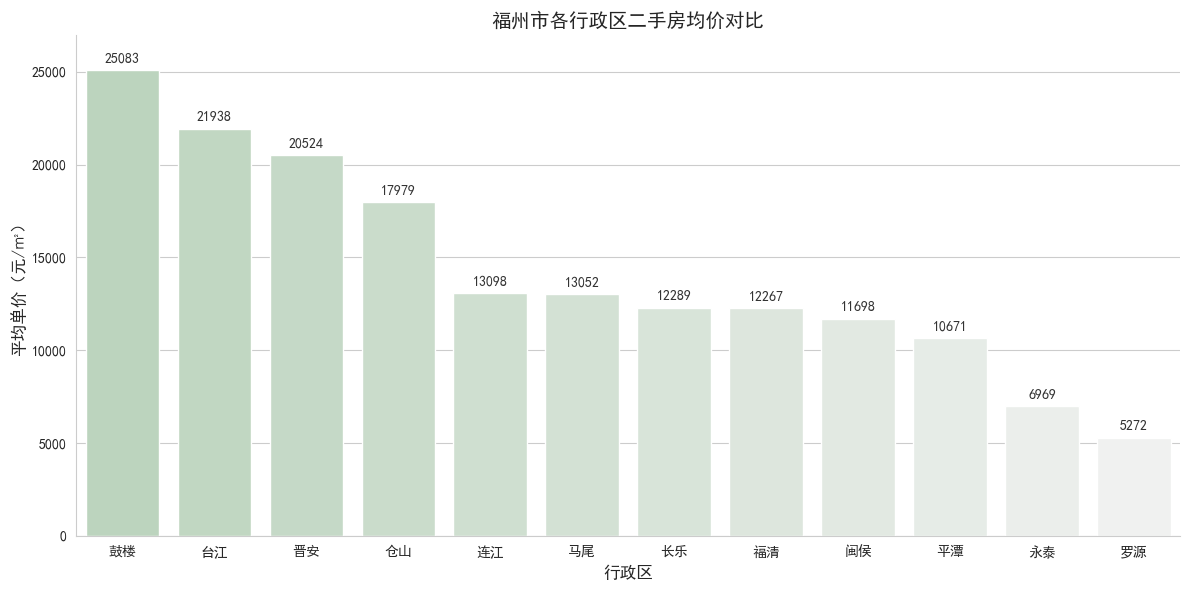

In [11]:
plt.figure(figsize=(12, 6))
light_green_palette = sns.light_palette("#B8D8BA", n_colors=len(district_stats), reverse=True)

sns.barplot(
    x=district_stats.index, 
    y='均价均值', 
    data=district_stats, 
    hue=district_stats.index,
    palette=light_green_palette,
    dodge=False,
    edgecolor='white'
)

sns.despine(top=True, right=True)

plt.title('福州市各行政区二手房均价对比', fontsize=14)
plt.xlabel('行政区', fontsize=12)
plt.ylabel('平均单价（元/㎡）', fontsize=12)
plt.ylim(0, 27000)

for i, v in enumerate(district_stats['均价均值']):
    plt.text(i, v + 400, f'{int(v)}', ha='center', fontsize=10, color='#333333')

plt.legend([], [], frameon=False)
plt.tight_layout()
plt.show()

**图表1 解读：**

该柱状图展示了福州下辖各行政区的二手房平均单价水平，横轴为行政区域，纵轴为每平方米平均价格（元/㎡），柱顶标注了对应区域的具体均价数值。

1.  **价格呈现三级梯队格局**：鼓楼、台江、晋安均价突破2万元/㎡，属于核心主城第一梯队，其中鼓楼区以25083元/㎡位居全市首位；仓山、连江、马尾均价在1.3万-1.8万元/㎡区间，属于近郊第二梯队；长乐、福清、闽侯等远郊县域均价低于1.3万元/㎡，罗源、永泰均价不足7000元/㎡，是全市购房门槛最低的区域。
2.  **圈层分化特征明显**：房价整体遵循“市中心—近郊—远郊”逐级递减的规律，最高的鼓楼区均价是最低的罗源县的近5倍，城市资源的聚集程度直接决定了房产的单价水平。
3.  **主城四区形成价格壁垒**：鼓楼、台江、晋安、仓山四区均价全部突破1.7万元/㎡，与外围县域形成清晰的价格断层，核心城区的教育、商业、交通等配套资源是房价的核心支撑，远郊区域则以刚需自住属性为主。

### 图表 2： 二手房总价分布直方图

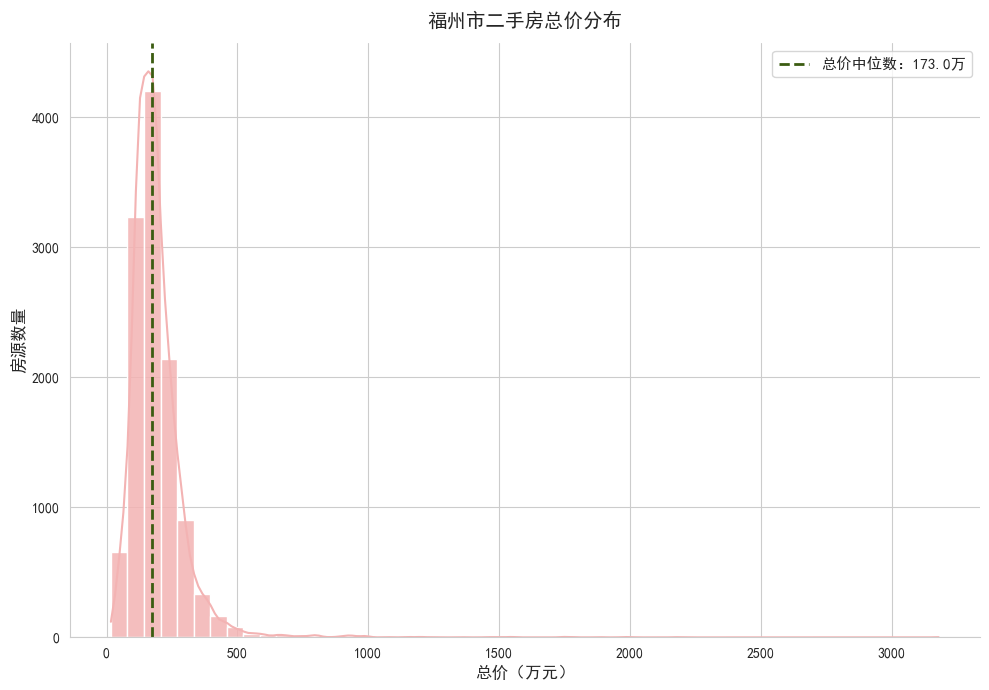

In [12]:
plt.figure(figsize=(10, 7))  

sns.histplot(
    clean_df['总价(万)'],
    bins=50,
    kde=True,
    color="#F3B3B3",       
    edgecolor='white',
    alpha=0.85
)

plt.title('福州市二手房总价分布', fontsize=14, pad=12)
plt.xlabel('总价（万元）', fontsize=12)
plt.ylabel('房源数量', fontsize=12)

# 中位数参考线
median_price = clean_df['总价(万)'].median()
plt.axvline(
    median_price,
    color="#3B5C11",  
    linestyle='--',
    linewidth=2,
    label=f'总价中位数：{median_price:.1f}万'
)

plt.legend(fontsize=11)
sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()

**图表2 解读：**

这是一张带核密度曲线的总价分布直方图，横轴为房屋总价（万元），纵轴为对应价位的房源数量，红色虚线标注了全市二手房总价中位数为173.0万元。

1.  **分布形态呈典型右偏特征**：房源数量的峰值集中在100-200万区间，说明该价位段是市场供给最集中的主力区间；随着总价升高，房源数量快速下降，高价位段形成长长的“尾部”，一直延伸至3000万级别，说明千万级以上的高价房源占比很低，属于市场少数派。
2.  **中位数反映市场真实门槛**：总价中位数173万元，意味着福州一半的二手房总价在173万以内，整体市场以刚需、刚改房源为绝对主体，普通家庭购房的主流预算集中在200万上下。
3.  **市场供给层次丰富**：在主流刚需房源之外，也存在一定数量的中高端改善房源，覆盖了从入门刚需到高端豪宅的全价位段需求。

### 图表 3： 面积与总价关系散点图（带回归线）

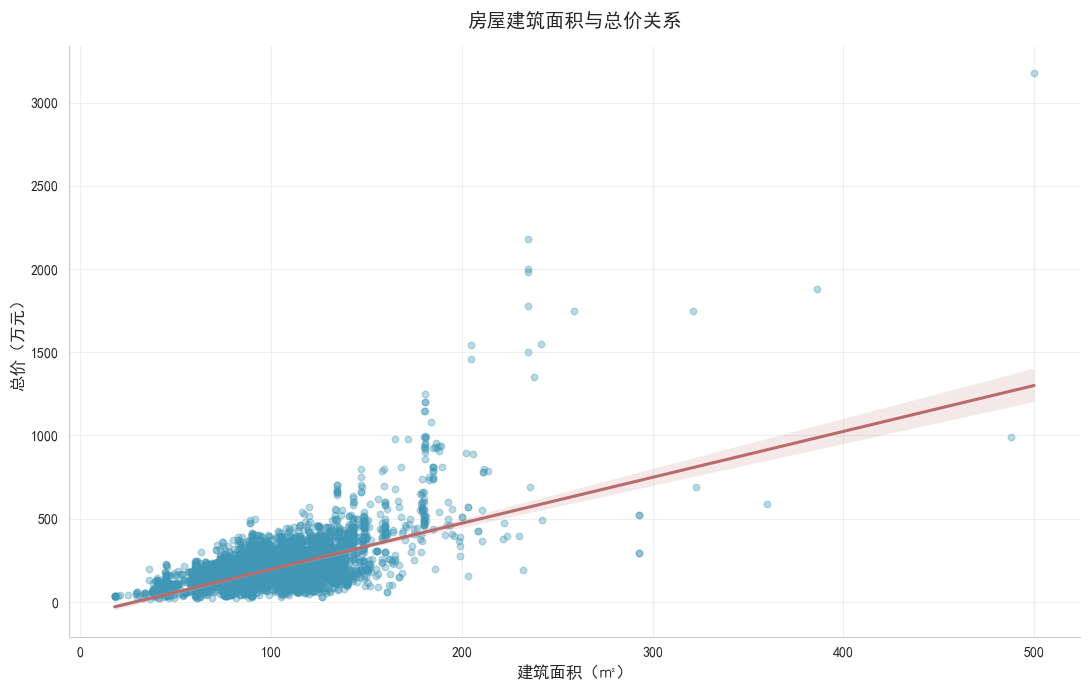

In [13]:
plt.figure(figsize=(11, 7))

sns.regplot(
    x='面积(㎡)',
    y='总价(万)',
    data=clean_df,
    scatter_kws={'alpha':0.35, 'color':"#4096B5", 's':22},  
    line_kws={'color':'#B86B6B', 'linewidth':2.2}           
)

plt.title('房屋建筑面积与总价关系', fontsize=14, pad=14)
plt.xlabel('建筑面积（㎡）', fontsize=12)
plt.ylabel('总价（万元）', fontsize=12)

sns.despine(top=True, right=True)
plt.grid(alpha=0.3, linestyle='-')

plt.tight_layout()
plt.show()

**图表3 解读：**

该图为散点回归图，横轴为房屋建筑面积（㎡），纵轴为房屋总价（万元），每个散点代表一套房源，红色直线为线性拟合回归线，粉色区域为置信区间。

1.  **面积与总价呈显著正相关**：整体趋势上，建筑面积越大，房屋总价越高，回归线清晰向上倾斜，符合“面积是决定房价的核心基础因素”的市场规律。
2.  **主流房源高度集中**：绝大多数散点聚集在200㎡以内、500万以下的区域，说明中小面积、中等总价的刚需/刚改房源是市场绝对主流。
3.  **大户型价格离散度更高**：当面积超过200㎡后，散点的上下分布明显变宽，同样面积的房源总价差异巨大。这说明大户型的总价除了受面积影响外，还高度依赖地段、小区品质、学区、装修等其他因素，价格分化更明显。
4.  **存在少量极端高价房源**：图中右上角存在个别总价超3000万的超大户型异常点，属于顶级豪宅类产品，拉高了整体价格上限。

### 图表 4： 各区域总价分布箱线图

C:\Users\TPF10\AppData\Local\Temp\ipykernel_2736\3558321172.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


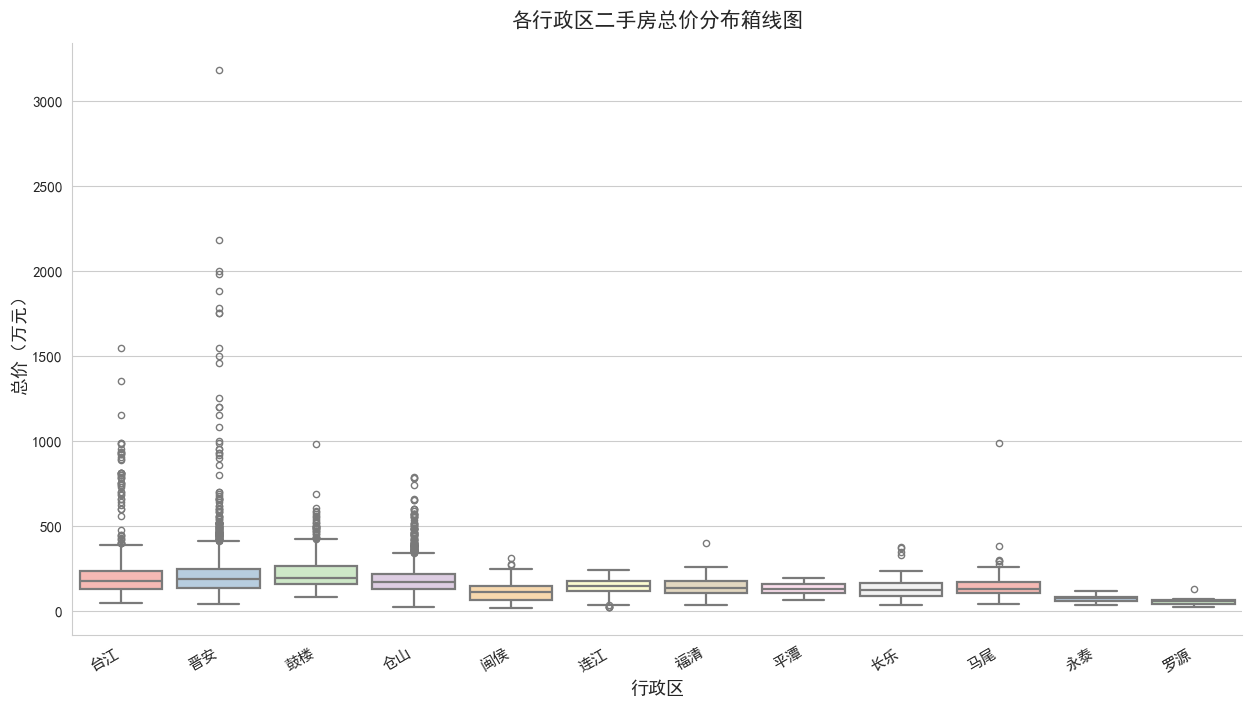

In [14]:
plt.figure(figsize=(13, 8))  

sns.boxplot(
    x='市区',
    y='总价(万)',
    data=clean_df,
    palette='Pastel1',
    width=0.85,       
    linewidth=1.6,     
    fliersize=4.5,     
    saturation=0.85
)

plt.title('各行政区二手房总价分布箱线图', fontsize=15, pad=12)
plt.xlabel('行政区', fontsize=13)
plt.ylabel('总价（万元）', fontsize=13)

plt.xticks(rotation=30, ha='right', fontsize=11)
plt.yticks(fontsize=11)

sns.despine(top=True, right=True)

plt.subplots_adjust(left=0.08, right=0.98, top=0.92, bottom=0.18)

plt.show()

**图表4 解读：**

箱线图中，箱体中间的横线为总价中位数，箱体上下沿分别代表75分位和25分位价格，上下须线为正常价格范围，超出须线的圆圈为高价异常值。

1.  **核心城区总价整体抬升**：鼓楼、台江、晋安、仓山四个主城区域的箱体位置显著更高，其中位数、上下四分位数均远高于外围县域，说明核心城区的购房门槛整体上了一个台阶。
2.  **核心区域高价房源密集**：鼓楼、晋安、台江的高价异常值数量最多，大量千万级甚至两千万级的房源集中在这几个区域，是福州高端改善和豪宅的主要分布地。
3.  **远郊区域价格高度集中**：永泰、罗源、平潭等远郊区域的箱体非常扁平，价格区间窄，几乎没有高价异常值，说明区域内房源总价普遍偏低，房源之间的价格差异小，刚需属性极强。
4.  **区域价差悬殊**：最贵区域的总价中位数是最便宜区域的数倍，直观体现了福州二手房市场“核心城区价值高、远郊县域门槛低”的圈层分化格局。

### 图表 5： 户型占比饼图

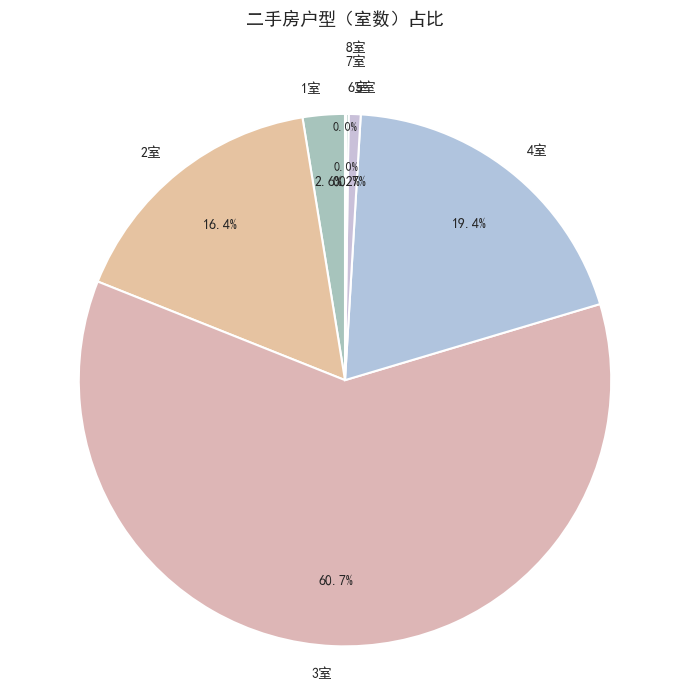

In [15]:
plt.figure(figsize=(7, 7))

# 扇区总数
n_sectors = len(room_dist)

morandi_colors = ['#A7C4BC', '#E6C3A1', '#DDB6B6', '#B0C4DE', '#C9C0D9'][:n_sectors]

explode = [0] * n_sectors
sorted_idx = room_dist['房源数量'].argsort().tolist()  # 按占比从小到大排序的索引
if len(sorted_idx) >= 1:
    explode[sorted_idx[0]] = 0.15  # 占比最小的扇区拉出最多
if len(sorted_idx) >= 2:
    explode[sorted_idx[1]] = 0.1   # 第二小的扇区轻微拉出

wedges, texts, autotexts = plt.pie(
    room_dist['房源数量'],
    labels=[f'{int(x)}室' for x in room_dist['室数']],
    autopct='%1.1f%%',
    colors=morandi_colors,
    startangle=90,
    explode=explode,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
    textprops={'fontsize': 10},
    pctdistance=0.75,
    labeldistance=1.1
)


for rank, idx in enumerate(sorted_idx[:2]):
    autotext = autotexts[idx]
    x, y = autotext.get_position()
    
    if rank == 0:
        autotext.set_position((x * 1.3, y + 0.05))
    else:
        autotext.set_position((x * 1.3, y - 0.05))
    autotext.set_fontsize(9)

plt.title('二手房户型（室数）占比', fontsize=13, pad=15)
plt.axis('equal')  
plt.tight_layout()
plt.show()

**图表5 解读：**

该饼图展示了不同室数户型在全部房源中的占比结构。

1.  **三居室是绝对市场主力**：3室户型占比高达60.7%，占据市场六成以上份额，是福州二手房市场的主流供给，也反映出三口之家的刚需、刚改需求是市场核心需求。
2.  **改善与刚需户型互为补充**：4室户型占比19.4%，2室户型占比16.4%，分别对应多孩家庭的改善需求和单身/两口之家的入门刚需需求，是市场的重要补充。
3.  **小户型供给稀缺**：1室及其他户型占比极低，说明一居室单身公寓、小户型产品在福州二手房市场中供给量很少，并非市场主流产品。

## 7. 主要结论

### 7.1 核心分析发现
本次分析通过对福州市二手房挂牌数据的探索性研究，总结出四项核心市场特征：
1.  **区域价格圈层分化明显，核心城区与远郊价差悬殊**。房价整体呈现由市中心向外围逐级递减的格局，城市配套资源的聚集程度直接决定了房产的价值水平。
2.  **刚需刚改房源占据市场主导，三居室供给占比超六成**。市场供给结构高度匹配家庭型居住需求，一居室等小户型产品供给占比极低。
3.  **二手房总价呈右偏分布，市场主流购房门槛集中在173万左右**。中低价位房源是市场供给主体，高价位房源占比稀少，整体市场偏向刚需定位。
4.  **建筑面积与总价呈显著正相关，大户型价格分化程度更高**。面积是影响房价的基础因素，而大户型房源受地段、小区品质等附加因素影响更大，价格离散度显著高于中小户型。

### 7.2 图表与统计结果支撑
上述结论均有对应分析结果作为数据支撑：
1.  区域价格分化结论由各行政区均价对比柱状图、各区域总价箱线图以及按市区分组的聚合统计结果共同支撑。数据显示鼓楼区均价达25083元/㎡，为全市最高，最低的罗源县仅5272元/㎡，二者差距接近5倍；箱线图进一步验证核心城区高价房源更密集，价格区间跨度更大。
2.  户型结构结论由二手房户型占比饼图支撑。数据显示3室户型占比达60.7%，占据市场六成以上份额；2室与4室户型分别占16.4%与19.4%，作为刚需与改善需求的补充；1室及其他小户型占比不足4%。
3.  总价分布结论由二手房总价分布直方图支撑。房源数量峰值集中在100-200万元区间，全市总价中位数为173.0万元，高价位段房源数量快速衰减，整体呈现典型的右偏分布形态。
4.  面积与价格的关联结论由房屋建筑面积与总价关系散点图支撑。回归趋势线清晰向上倾斜，验证了二者的正相关关系；同时200㎡以上大户型的散点分布明显更分散，体现出更强的价格分化特征。

### 7.3 数据局限与谨慎说明
本次分析存在以下局限性，相关结论需结合实际场景谨慎解读：
1.  **价格属性局限**：本次使用数据为二手房挂牌价格，与实际成交价格普遍存在议价空间，结论仅能反映挂牌市场的价格特征，无法完全等同于真实交易市场的价格水平。
2.  **时间维度局限**：数据为单一时间节点的截面样本，不包含历史价格变动信息，无法用于推断福州二手房价格的涨跌趋势，结论仅代表当前样本时点的市场状态。
3.  **变量维度局限**：数据集未包含装修标准、学区等级、物业品质、地铁通勤距离等对房价有重要影响的细节变量，无法精准量化各因素对房价的贡献程度，价格差异的归因解释需保持克制。
4.  **极端值干扰**：样本中包含少量千万级以上的高价异常房源，会对区域均价、总价均值等指标产生拉高作用，描述市场普遍价格水平时，中位数指标比均值更具参考性。